<a href="https://colab.research.google.com/github/Ibrah-N/PNID_Custom_OCR_Training_Detector_Recognizer/blob/main/PNID_OCR_Data_Preparation_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Orientation Helpers

In [ ]:
import math
import numpy as np


def xywhrot_xyxyxyxy(label, percentages=True):
  """
  Converting Label Studio format into Oriented Bounding Box (OBB) format.

  Args:
    label (dict): Dictionary containing annotation information
    percentages (bool): if true it will convert percenatage values into pixels values

  Maths:
    label:
      x, y, width, height, rotation

      if percentages:
        x = x / 100 * original_width
        y = y / 100 * original_height
        w = width / 100 * original_width
        h = height / 100 * original_height

      rotation:
        rotation_ = math.radians(rotation)
        cos, sin = math.cos(rotation_), math.sin(rotation_)

        coords = [
          (x, y),
          (x + w * cos, y + w * sin),
          (x + w * cos - h * sin, y + w * sin + h * cos),
          (x - h * sin, y + h * cos),
        ]

  Returns:
    list of tuple or None: List of tuples containing the coordinates of the object in Yolo OBB
  """

  # unpick values
  original_width = label['original_width']
  original_height = label['original_height']
  x, y = label['x'], label['y']
  w, h = label['width'], label['height']
  rotation = label['rotation']


  if percentages:
    x = x / 100 * original_width
    y = y / 100 * original_height
    w = w / 100 * original_width
    h = h / 100 * original_height

  # rotation -> angles
  rotation = math.radians(rotation)
  cos, sin = math.cos(rotation), math.sin(rotation)

  # xywhr -> xyxyxyxy
  coords = [
      (x, y),
      (x + w * cos, y + w * sin),
      (x + w * cos -h * sin, y + w * sin + h * cos),
      (x - h * sin, y + h * cos)
  ]

  return np.array(coords, dtype=np.int32)





def xyxyxyxy_xywhr(xyxyxyxy, original_width, original_height):
  """
    Convert YOLO Oriented Bounding Box (OBB) format to Label Studio format.

    Args:
        xyxyxyxy (list): List of 8 float values representing the absolute pixel coordinates
                         of the OBB in the format [x1, y1, x2, y2, x3, y3, x4, y4]
        original_width (int): Original width of the image
        original_height (int): Original height of the image


    Return:
        dict: Dictionary containing the converted bounding box
              list: [x, y, width, height, rotation, original_width, original_height]
  """
  # Reshape the coordinates into a 4x2 matrix
  coords = np.array(xyxyxyxy, dtype=np.float64).reshape((4, 2))

  # Calculate the center of the bounding box
  center_x = np.mean(coords[:, 0])
  center_y = np.mean(coords[:, 1])

  # Calculate the width and height of the bounding box
  width = np.linalg.norm(coords[0] - coords[1])
  height = np.linalg.norm(coords[0] - coords[3])

  # Calculate the rotation angle
  dx = coords[1, 0] - coords[0, 0]
  dy = coords[1, 1] - coords[0, 1]
  r = np.degrees(np.arctan2(dy, dx))

  # Find the top-left corner (x, y)
  top_left_x = (
      center_x
      - (width / 2) * np.cos(np.radians(r))
      + (height / 2) * np.sin(np.radians(r))
  )
  top_left_y = (
      center_y
      - (width / 2) * np.sin(np.radians(r))
      - (height / 2) * np.cos(np.radians(r))
  )

  # Normalize the values
  x = (top_left_x / original_width) * 100
  y = (top_left_y / original_height) * 100
  width = (width / original_width) * 100
  height = (height / original_height) * 100

  # Create the dictionary for Label Studio
  return {
      "x": x,
      "y": y,
      "width": width,
      "height": height,
      "rotation": r,
      "original_width": original_width,
      "original_height": original_height,
  }

# Label-Studio Import Code

### Installation

#### GPU Installation

In [ ]:
!nvidia-smi

Mon Apr 20 05:33:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!python3 -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu130/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 775.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 613.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import paddle

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


In [ ]:
paddle.device.get_device()

'gpu:0'

In [ ]:
!pip install paddleocr==3.3.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/

In [ ]:
!pip install langchain==1.2.15 langchain-community==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is

In [ ]:
# update the base.py file
'''
if is_dep_available("langchain"):
    from langchain_core.documents import Document
    from langchain_text_splitters import RecursiveCharacterTextSplitter
'''


In [ ]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 72.5 MB/s eta 0:00:00


#### CPU Installation

In [ ]:
!pip install paddleocr==3.3.1

In [ ]:
!python -m pip install paddlepaddle==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.9/192.9 MB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


In [ ]:
!pip install langchain==1.2.15 langchain-community==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
!pip install PyMuPDF

In [ ]:
# update the base.py file
'''
if is_dep_available("langchain"):
    from langchain_core.documents import Document
    from langchain_text_splitters import RecursiveCharacterTextSplitter
'''


### Utils

In [ ]:
# general
import cv2
import os
import uuid
import copy
import json
import numpy as np

# pdf 2 image
import fitz               # PyMuPDF
from PIL import Image, ImageFilter

# model
from paddleocr import PaddleOCR






def modified_xyxyxyxy_xywhr(xyxyxyxy, original_width, original_height):
  """
    Convert YOLO Oriented Bounding Box (OBB) format to Label Studio format.

    Args:
        xyxyxyxy (list): List of 8 float values representing the absolute pixel coordinates
                         of the OBB in the format [x1, y1, x2, y2, x3, y3, x4, y4]
        original_width (int): Original width of the image
        original_height (int): Original height of the image


    Return:
        dict: Dictionary containing the converted bounding box
              list: [x, y, width, height, rotation, original_width, original_height]
  """
  # Reshape the coordinates into a 4x2 matrix
  coords = np.array(xyxyxyxy, dtype=np.float64).reshape((4, 2))

  # Calculate the center of the bounding box
  center_x = np.mean(coords[:, 0])
  center_y = np.mean(coords[:, 1])

  # Calculate the width and height of the bounding box
  width = np.linalg.norm(coords[0] - coords[1])
  height = np.linalg.norm(coords[0] - coords[3])

  # Calculate the rotation angle
  dx = coords[1, 0] - coords[0, 0]
  dy = coords[1, 1] - coords[0, 1]
  r = np.degrees(np.arctan2(dy, dx))

  # Find the top-left corner (x, y)
  top_left_x = (
      center_x
      - (width / 2) * np.cos(np.radians(r))
      + (height / 2) * np.sin(np.radians(r))
  )
  top_left_y = (
      center_y
      - (width / 2) * np.sin(np.radians(r))
      - (height / 2) * np.cos(np.radians(r))
  )

  # Normalize the values
  x = (top_left_x / original_width) * 100
  y = (top_left_y / original_height) * 100
  width = (width / original_width) * 100
  height = (height / original_height) * 100

  # Create the dictionary for Label Studio
  return {
      "x": x,
      "y": y,
      "width": width,
      "height": height,
      "rotation": r,
  }



def pdf_2_image(pdf_path,
                dpi=300, threshold=220,
                pdf_id=0, blur_radius=0.5,
                output_folder_color="color_imgs",
                color_flag=False):
  """
    Convert each page of a PDF to:
      • color_image_<page>.jpg
      • bw_image_<page>.jpg


    NOTE: This function is written by Harri Vinod

    Args:
      pdf_path (str): path to .pdf file
      output_folder_color (str): where to save JPEGs
      dpi (int): rendering resolution
      threshold (0–255): gray cutoff for B/W
      blur_radius (float): Gaussian blur radius on B/W
      pdf_id (index per pdf): if directory has multiple pdf each pdf indexed
      color_flag (bool): define to save the color pdf page image into the output_folder_color path

    Return:
      pages
  """

  print("Processing the pdf {} ....".format(pdf_path))


  pdf_pages_list = []

  doc = fitz.open(pdf_path)
  page_count = doc.page_count

  for Idx, pdf_page in enumerate(doc, start=1):
    pix = pdf_page.get_pixmap(dpi=dpi)
    page_image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

    # color - JPEG
    if color_flag:

      os.makedirs(output_folder_color, exist_ok=True)

      color_file = os.path.join(output_folder_color, f"color_image_{Idx}.jpg")
      page_image.save(color_file, "JPEG", quality=100, dpi=(dpi, dpi))

    # — Grayscale → threshold → blur → B/W JPEG
    gray = page_image.convert("L")
    bw = gray.point(lambda x: 255 if x > threshold else 0)
    bw = bw.filter(ImageFilter.GaussianBlur(blur_radius))

    pdf_pages_list.append({"image":bw, "name": pdf_path.split("/")[-1]})

  doc.close()
  print(f"Done! For pdf {pdf_id} Returned {page_count} page(s)'")

  return pdf_pages_list




def patch_image(image, image_name,
                patch_size, overlap_ratio):
  """Splits image into overlapping patches using cv2.

    - overlap_ratio: 0.0 -> no overlap, 0.5 -> 50% overlap
    - If image is smaller than patch_size -> resize
  """

  print("Patching the image {} ....".format(image_name))

  # convert PIL → numpy
  if not isinstance(image, np.ndarray):
      image = np.array(image)

  print("shape {}".format(image.shape))
  if len(image.shape) != 3:
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

  h, w = image.shape[:2]

  # resize if image is too small
  if h < patch_size or w < patch_size:
      image = cv2.resize(image, (patch_size, patch_size))
      h, w = patch_size, patch_size

  # compute stride
  stride = int(patch_size * (1 - overlap_ratio))
  stride = max(1, stride)  # safety

  patches = []

  for Idx_y, y in enumerate(range(0, h, stride)):
    for Idx_x, x in enumerate(range(0, w, stride)):

      # ensure patch stays within bounds
      y_end = min(y + patch_size, h)
      x_end = min(x + patch_size, w)

      patch = image[y:y_end, x:x_end]

      ph, pw = patch.shape[:2]

      # pad if needed
      if ph < patch_size or pw < patch_size:
          padded = np.zeros((patch_size, patch_size, 3), dtype=image.dtype)
          padded[:ph, :pw] = patch
          patch = padded

      # patch name
      filename = f"{image_name[:-4]}__{str(uuid.uuid4())}.jpg"

      patches.append({"image": patch, "name": filename})


  # return patches
  return patches




def save_patch(patch, patch_save_path):
  """Save patches into a folder
  """

  print("Saving the Patched image {} ....".format(patch_save_path))

  # save patch
  cv2.imwrite(patch_save_path, np.array(patch))



def load_model():
  """Load PPOCR_V5 Model
  """

  print("Loading the Model PPOCR_V5 ....")
  load_model = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False)

  return load_model



def read_image(image_path):
  """Read Image into array

  Args:
    image_path: the path to the image

  Return:
    return numpy array
  """
  if not (image_path.lower().endswith(".jpg") or
      image_path.lower().endswith(".png")):
    print("Invalid image path: {}".format(image_path))
    return None

  # read image
  image = cv2.imread(image_path)

  if image is None:
    print("Could not load image from: {}".format(image_path))
    return None

  # return image
  return image




def detect_text(image):
  """It detect the text and return the boxes and texts
  """

  print("Running Model for the patch ....")

  # Run OCR inference on a sample image
  global ocr_model
  model_result = ocr_model.predict(
    input=image
  )

  if model_result is None:
    print("Could not detect text from image")

  polygons = model_result[0].get("dt_polys") # get polygons [[], [], [], []] --> 4, 2 shape
  texts = model_result[0].get("rec_texts")


  # return polygons and texts
  return polygons, texts





def make_results_object(polygon, text,
                        original_width,
                        original_height
                        ):
  """It create a single object per annotation
  """

  generic_object = {
      "original_width": original_width,
      "original_height": original_height,
      "image_rotation": 0,
      "value": polygon,
      "id": str(uuid.uuid4()),
      "to_name": "image"
  }


  # box object
  box_object = copy.deepcopy(generic_object)
  box_object["from_name"] = "bbox"
  box_object["type"] = "rectangle"


  # label object
  label_object = copy.deepcopy(generic_object)
  label_object["value"]["labels"] = ['Text']
  label_object["from_name"] = "label"
  label_object["type"] = "labels"


  # transcription object
  transcription_object = copy.deepcopy(generic_object)
  transcription_object["value"]["text"] = [text]
  transcription_object["from_name"] = "transcription"
  transcription_object["type"] = "textarea"


  # returns
  return box_object, label_object, transcription_object



def create_json_object(results,
                       image_name,
                       global_path):
  """Create a single object of one single detection
  """

  print("Creating Complete Object ....")

  final_object = {}

  # data object
  data_object = {
      "data": {
          "ocr": os.path.join(global_path, image_name)
      }
  }


  # final object
  final_object.update(data_object)
  final_object["predictions"] = [
      {
        "model_version": "PPOCR_V5",
        "result": results,
        "score": 0.0
       }
      ]


  # append to global list
  global global_list
  global_list.append(final_object)




def parse_polygons_and_text(polygons, texts,
                            original_width,
                            original_height,
                            image_name,
                            global_path):
  """It parse the polygons and texts
  """

  print("Parsing Polygons and Texts ....")

  results = []

  # if there are detected polygons and texts
  if not ((polygons is None or len(polygons)==0) or
         (texts is None or len(texts)==0)):

    for pt, text in zip(polygons, texts):

      # xyxyxyxy --> xywhrot
      polygon = modified_xyxyxyxy_xywhr(
                xyxyxyxy=pt,
                original_width=original_width,
                original_height=original_height)

      # make objects
      box_object, label_object, transcription_object = make_results_object(
                                              polygon=polygon, text=text,
                                              original_width=original_width,
                                              original_height=original_height)

      # results [{box}, {label}, {transcription}....]
      results.append(box_object)
      results.append(label_object)
      results.append(transcription_object)


  create_json_object(results=results,
                    image_name=image_name,
                    global_path=global_path)



def flag_patch_main(dir_path, global_path,
                    save_path, patch_size,
                    overlap_ratio):
  """Main function to run the script for pdf and
  unpatched images if the flag is set to True in
  the main function.....
  """
  for image_name in os.listdir(dir_path):

    image_path = os.path.join(dir_path, image_name)

    # if pdf
    if image_path.lower().endswith(".pdf"):

      print("STARTED:  Processing PDF: {}".format(image_path))

      pdf_pages_list = pdf_2_image(pdf_path=image_path,
                                dpi=300, threshold=220,
                                pdf_id=0, blur_radius=0.5,
                                output_folder_color="color_imgs",
                                color_flag=False)

      if (pdf_pages_list is None or
          len(pdf_pages_list) == 0):
        continue

      for pdf_Idx, pdf_page in enumerate(pdf_pages_list):

        image = pdf_page.get("image")
        image_name = pdf_page.get("name")


        patches = patch_image(image=image,
                              image_name=image_name,
                              patch_size=patch_size,
                              overlap_ratio=overlap_ratio)

        if patches is None or len(patches) == 0:
          continue

        for patch_Idx, patch in enumerate(patches):

          image = patch.get("image")
          image_name = patch.get("name")

          # detect polygons and texts
          polygons, texts = detect_text(image)


          # create json
          original_height, original_width = image.shape[:2]
          parse_polygons_and_text(polygons=polygons, texts=texts,
                                  original_height=original_height,
                                  original_width=original_width,
                                  image_name=image_name,
                                  global_path=global_path)

          # save the patch
          patch_save_path = os.path.join(save_path, image_name)
          save_patch(patch=image,
                       patch_save_path=patch_save_path)

          print("ENDED: Patch {} Processed & Saved Successfully to {}"
                .format(image_name, patch_save_path))
          print()


    # if jpg or png
    if image_path.lower().endswith((".jpg", ".png")):

      print("STARTED: Processing Image: {}".format(image_path))

      image = read_image(image_path)

      if image is None:
        continue

      patches = patch_image(image=image,
                              image_name=image_name,
                              patch_size=patch_size,
                              overlap_ratio=overlap_ratio)

      if patches is None or len(patches) == 0:
        continue

      for patch_Idx, patch in enumerate(patches):

        image = patch.get("image")
        image_name = patch.get("name")

        # detect polygons and texts
        polygons, texts = detect_text(image)


        # create json
        original_height, original_width = image.shape[:2]
        parse_polygons_and_text(polygons=polygons, texts=texts,
                                original_height=original_height,
                                original_width=original_width,
                                image_name=image_name,
                                global_path=global_path)

        # save the patch
        patch_save_path = os.path.join(save_path, image_name)
        save_patch(patch=image,
                  patch_save_path=patch_save_path)

        print("ENDED: Patch {} Processed & Saved Successfully to {}"
              .format(image_name, patch_save_path))
        print()

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


### Main

In [ ]:
if __name__ == '__main__':

  # === IMPORTANT GLOBAL VARIBALES !!!!===
  global_list = [] # stores the objects {{data}, predictions: {results: [{box}, {label}, {transcription} ....]}}
  ocr_model = load_model() # load PPOCR_V5 Model


  # -- local variables --
  patch_size = 1792
  # it should be 0-1: shows percentages (0.4 mean 40% overlap)
  overlap_ratio = 0


  # -- paths --
  dir_path = "/content/patches"
  global_path = "/data/local-files/?d=ocr_dataset"

  save_path = "/content/patches__" # patches paths
  json_path = "/content/import_json.json"

  os.makedirs(save_path, exist_ok=True)


  # -- main --
  flag_patch_main(dir_path=dir_path,
                  global_path=global_path,
                  save_path=save_path,
                  patch_size= patch_size,
                  overlap_ratio=overlap_ratio)


  # -- write global json --
  json_object = json.dumps(global_list, indent=4)
  with open(json_path, "w") as outfile:
    outfile.write(json_object)

Loading the Model PPOCR_V5 ....


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to acce

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

STARTED: Processing Image: /content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0019__f87463c9-04c4-4d0c-9a2f-e3d3b6e405ef.jpg
Patching the image 495186439-90-60C-10512-A07A-A-00A-001_page-0019__f87463c9-04c4-4d0c-9a2f-e3d3b6e405ef.jpg ....
shape (1792, 1792, 3)
Running Model for the patch ....
Parsing Polygons and Texts ....
Creating Complete Object ....
Saving the Patched image /content/patches__/495186439-90-60C-10512-A07A-A-00A-001_page-0019__f87463c9-04c4-4d0c-9a2f-e3d3b6e405ef__4d944df3-6612-4ace-a156-d206c016ac36.jpg ....
ENDED: Patch 495186439-90-60C-10512-A07A-A-00A-001_page-0019__f87463c9-04c4-4d0c-9a2f-e3d3b6e405ef__4d944df3-6612-4ace-a156-d206c016ac36.jpg Processed & Saved Successfully to /content/patches__/495186439-90-60C-10512-A07A-A-00A-001_page-0019__f87463c9-04c4-4d0c-9a2f-e3d3b6e405ef__4d944df3-6612-4ace-a156-d206c016ac36.jpg

STARTED: Processing Image: /content/patches/494201659-99-TEG-10969-A07A-A-00A-001_page-0001__cf28adde-4158-4ff7-b641-268ce31a7832.jpg
P

In [ ]:
!zip -r /content/test_labels_v2.zip /content/patches

In [ ]:
len(os.listdir("/content/patches"))

16

# Pixilated Iosmetric Parsing

## installations

In [ ]:
!pip install -q pdf2image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 44.2 MB/s eta 0:00:00


In [ ]:
!apt-get install poppler-utils

## Utils

In [ ]:
import cv2
import os
import uuid
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
from pdf2image import convert_from_path
from pathlib import Path


def pdf_to_readable_images(
    pdf_path: str | Path,
    output_dir: str | Path | None = None,
    dpi: int = 400,
    fmt: str = "png",
) -> list[Image.Image]:
    """
    Convert a P&ID PDF to images with maximum text readability.
    Optimised for: white background, black lines/text.

    Args:
        pdf_path:   Path to the source PDF.
        output_dir: If provided, saves each page here.
        dpi:        Render resolution. 400 is a safe default for P&IDs.
        fmt:        Output format — always use "png" for lossless output.

    Returns:
        List of enhanced PIL Images, one per page.
    """
    pdf_path = Path(pdf_path)
    images = convert_from_path(pdf_path, dpi=dpi)

    enhanced = []
    for img in images:
        img = _enhance_text(img)
        enhanced.append(img)

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        for i, img in enumerate(enhanced, start=1):
            img.save(output_dir / f"{pdf_path.stem}_page_{i}.{fmt}", fmt.upper())

    return enhanced



def _enhance_text(img: Image.Image) -> Image.Image:
    """
    Three-step pipeline targeting text clarity on white-background P&IDs:

      1. Contrast boost  — makes black ink darker, white background whiter
      2. Adaptive threshold — cleans up grey "muddy" pixels around text edges
      3. Anti-aliased upscale → downscale — removes jagged pixelation on glyphs
    """
    # --- Step 1: Boost contrast so black text is truly black ---
    img = ImageEnhance.Contrast(img).enhance(2.0)
    img = ImageEnhance.Sharpness(img).enhance(2.5)

    # --- Step 2: Adaptive thresholding — kills grey mud around text edges ---
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)

    clean = cv2.adaptiveThreshold(
        gray,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=15,   # Neighbourhood size — increase for larger text
        C=10,           # Constant subtracted from mean — increase to whiten bg
    )

    # Back to RGB so it stays consistent with PIL
    clean_rgb = cv2.cvtColor(clean, cv2.COLOR_GRAY2RGB)

    # --- Step 3: Super-resolution trick — upscale then downscale with LANCZOS ---
    # This anti-aliases jagged glyph edges without blurring strokes
    pil = Image.fromarray(clean_rgb)
    w, h = pil.size
    pil = pil.resize((w * 2, h * 2), Image.LANCZOS)   # 2× up
    pil = pil.resize((w, h), Image.LANCZOS)            # back down — smooths pixels

    return pil




def patch_image(image, image_name,
                patch_size, overlap_ratio):
  """Splits image into overlapping patches using cv2.

    - overlap_ratio: 0.0 -> no overlap, 0.5 -> 50% overlap
    - If image is smaller than patch_size -> resize
  """

  print("Patching the image {} ....".format(image_name))

  # convert PIL → numpy
  if not isinstance(image, np.ndarray):
      image = np.array(image)

  print("shape {}".format(image.shape))
  if len(image.shape) != 3:
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

  h, w = image.shape[:2]

  # resize if image is too small
  if h < patch_size or w < patch_size:
      image = cv2.resize(image, (patch_size, patch_size))
      h, w = patch_size, patch_size

  # compute stride
  stride = int(patch_size * (1 - overlap_ratio))
  stride = max(1, stride)  # safety

  patches = []

  for Idx_y, y in enumerate(range(0, h, stride)):
    for Idx_x, x in enumerate(range(0, w, stride)):

      # ensure patch stays within bounds
      y_end = min(y + patch_size, h)
      x_end = min(x + patch_size, w)

      patch = image[y:y_end, x:x_end]

      ph, pw = patch.shape[:2]

      # pad if needed
      if ph < patch_size or pw < patch_size:
          padded = np.zeros((patch_size, patch_size, 3), dtype=image.dtype)
          padded[:ph, :pw] = patch
          patch = padded

      # patch name
      filename = f"{image_name[:-4]}__{str(uuid.uuid4())}.jpg"

      patches.append({"image": patch, "name": filename})


  # return patches
  return patches

## Main

In [ ]:
pdfs_path = "/content/bad_pdfs/Bad isometric"
save_images_path = "/content/patches"
dpi_resolution = 600

os.makedirs(save_images_path, exist_ok=True)


for pdf_idx, pdf_name in enumerate(os.listdir(pdfs_path)):
  pdf_path = os.path.join(pdfs_path, pdf_name)

  if not pdf_path.lower().endswith(".pdf"):
    print("Not a pdfs file ---> {}".format(pdf_name))
    continue

  print("STARTED: No {} - Processing PDF: {}".format(pdf_idx, pdf_path))

  # pdf to images
  images = pdf_to_readable_images(pdf_path=pdf_path, dpi=dpi_resolution)


  # if fails to convert pdf into images
  if images is None or len(images) == 0:
    print("No images found in pdf: {}".format(pdf_path))
    continue


  for img_idx, image in enumerate(images):
    patches = patch_image(image=image, image_name=pdf_name,
                              patch_size=1792, overlap_ratio=0.2)

    if patches is None or len(patches) == 0:
      continue

    for patch_idx, patch in enumerate(patches):
      image_name = patch.get("name")
      pdf_image = patch.get("image")

      save_path = os.path.join(save_images_path, image_name)
      cv2.imwrite(save_path, pdf_image)

      print("Patch {} Processed & Saved Successfully to {}"
            .format(image_name, save_path))

  print("COMPLETED: No {} - Processing PDF: {}".format(pdf_idx, pdf_path))
  print()

STARTED: Processing PDF: /content/bad_pdfs/Bad isometric/495186439-90-60C-10512-A07A-A-00A-001_page-0029.pdf
Patching the image 495186439-90-60C-10512-A07A-A-00A-001_page-0029.pdf ....
shape (7016, 4961, 3)
Patch 495186439-90-60C-10512-A07A-A-00A-001_page-0029__1f761cc8-f32a-4391-839c-b45b987d8535.jpg Processed & Saved Successfully to /content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0029__1f761cc8-f32a-4391-839c-b45b987d8535.jpg
Patch 495186439-90-60C-10512-A07A-A-00A-001_page-0029__bff33a95-feb6-42e8-9744-707e01e482a5.jpg Processed & Saved Successfully to /content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0029__bff33a95-feb6-42e8-9744-707e01e482a5.jpg
Patch 495186439-90-60C-10512-A07A-A-00A-001_page-0029__439645a6-1ad0-415d-8f0d-a19b6ea368c9.jpg Processed & Saved Successfully to /content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0029__439645a6-1ad0-415d-8f0d-a19b6ea368c9.jpg
Patch 495186439-90-60C-10512-A07A-A-00A-001_page-0029__92c8bb6b-80e3-4da5-9607-1a9

In [ ]:
!zip -r /content/patched_bad_pdfs.zip /content/patches

  adding: content/patches/ (stored 0%)
  adding: content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0019__f87463c9-04c4-4d0c-9a2f-e3d3b6e405ef.jpg (deflated 99%)
  adding: content/patches/494201659-99-TEG-10969-A07A-A-00A-001_page-0001__cf28adde-4158-4ff7-b641-268ce31a7832.jpg (deflated 95%)
  adding: content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0026__4a8bb4f5-e0fa-4121-953a-5255a436178d.jpg (deflated 15%)
  adding: content/patches/494201659-99-TEG-10969-A07A-A-00A-001_page-0013__32d2f161-c9fa-4d17-a9ef-a6442ab19c64.jpg (deflated 14%)
  adding: content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0007__c178fbb1-8166-4519-9ba6-72391376a3a5.jpg (deflated 23%)
  adding: content/patches/495186439-90-60C-10512-A07A-A-00A-001_page-0029__141f5cac-1217-489f-8981-986e3db6116c.jpg (deflated 16%)
  adding: content/patches/494201659-99-TEG-10969-A07A-A-00A-001_page-0011__29f84c16-4077-4912-84f1-21b7077ab405.jpg (deflated 14%)
  adding: content/patches/495186439-90-60C-1

In [ ]:
!cp -r /content/patched_bad_pdfs.zip -d /content/Ibrah/MyDrive/PNID_OCR_V2/data

# Processing Isometric Annotated Data

In [1]:
from google.colab import drive
drive.mount('/content/Ibrah')

Mounted at /content/Ibrah


## Utils

In [35]:
#====================================#
#   D A T A - L O A D - C L A S S    #
#====================================#

import os
import json
import math
import numpy as np
import cv2


def load_json(json_path):
  """load json from json path"""

  if os.path.exists(json_path) and json_path.lower().endswith(".json"):
    with open(json_path, "r") as f:
      jsons_list = json.load(f)
  else:
    raise ValueError(f"Invalid json path: {json_path}")

  return jsons_list



def read_image(image_path):
  """read image from the image path"""

  if image_path.lower().endswith(".jpg") or image_path.lower().endswith(".png"):
    image = cv2.imread(image_path)
  else:
    print("Invalid image path: {}".format(image_path))
    return None

  return image




def xywhrot_xyxyxyxy(label, percentages=True):
  """
  Converting Label Studio format into Oriented Bounding Box (OBB) format.

  Args:
    label (dict): Dictionary containing annotation information
    percentages (bool): if true it will convert percenatage values into pixels values

  Maths:
    label:
      x, y, width, height, rotation

      if percentages:
        x = x / 100 * original_width
        y = y / 100 * original_height
        w = width / 100 * original_width
        h = height / 100 * original_height

      rotation:
        rotation_ = math.radians(rotation)
        cos, sin = math.cos(rotation_), math.sin(rotation_)

        coords = [
          (x, y),
          (x + w * cos, y + w * sin),
          (x + w * cos - h * sin, y + w * sin + h * cos),
          (x - h * sin, y + h * cos),
        ]

  Returns:
    list of tuple or None: List of tuples containing the coordinates of the object in Yolo OBB
  """

  # unpick values
  original_width = label['original_width']
  original_height = label['original_height']
  x, y = label['x'], label['y']
  w, h = label['width'], label['height']
  rotation = label['rotation']


  if percentages:
    x = x / 100 * original_width
    y = y / 100 * original_height
    w = w / 100 * original_width
    h = h / 100 * original_height

  # rotation -> angles
  rotation = math.radians(rotation)
  cos, sin = math.cos(rotation), math.sin(rotation)

  # xywhr -> xyxyxyxy
  coords = [
      (x, y),
      (x + w * cos, y + w * sin),
      (x + w * cos -h * sin, y + w * sin + h * cos),
      (x - h * sin, y + h * cos)
  ]

  return np.array(coords, dtype=np.int32)





def xyxyxyxy_xywhr(xyxyxyxy, original_width, original_height):
  """
    Convert YOLO Oriented Bounding Box (OBB) format to Label Studio format.

    Args:
        xyxyxyxy (list): List of 8 float values representing the absolute pixel coordinates
                         of the OBB in the format [x1, y1, x2, y2, x3, y3, x4, y4]
        original_width (int): Original width of the image
        original_height (int): Original height of the image


    Return:
        dict: Dictionary containing the converted bounding box
              list: [x, y, width, height, rotation, original_width, original_height]
  """
  # Reshape the coordinates into a 4x2 matrix
  coords = np.array(xyxyxyxy, dtype=np.float64).reshape((4, 2))

  # Calculate the center of the bounding box
  center_x = np.mean(coords[:, 0])
  center_y = np.mean(coords[:, 1])

  # Calculate the width and height of the bounding box
  width = np.linalg.norm(coords[0] - coords[1])
  height = np.linalg.norm(coords[0] - coords[3])

  # Calculate the rotation angle
  dx = coords[1, 0] - coords[0, 0]
  dy = coords[1, 1] - coords[0, 1]
  r = np.degrees(np.arctan2(dy, dx))

  # Find the top-left corner (x, y)
  top_left_x = (
      center_x
      - (width / 2) * np.cos(np.radians(r))
      + (height / 2) * np.sin(np.radians(r))
  )
  top_left_y = (
      center_y
      - (width / 2) * np.sin(np.radians(r))
      - (height / 2) * np.cos(np.radians(r))
  )

  # Normalize the values
  x = (top_left_x / original_width) * 100
  y = (top_left_y / original_height) * 100
  width = (width / original_width) * 100
  height = (height / original_height) * 100

  # Create the dictionary for Label Studio
  return {
      "x": x,
      "y": y,
      "width": width,
      "height": height,
      "rotation": r,
      "original_width": original_width,
      "original_height": original_height,
  }





def put_text_on_polygon_simple(image, polygon, text,
                              font=cv2.FONT_HERSHEY_SIMPLEX,
                              font_scale=0.5,
                              thickness=1,
                              color=(0, 255, 0)):

    polygon = polygon.reshape(-1, 2).astype(int)

    # ---- 1. Get top-left point ----
    # smallest y → top, then smallest x → left
    top_left = sorted(polygon, key=lambda p: (p[1], p[0]))[0]

    x, y = top_left

    # ---- 2. Get text size ----
    (w, h), baseline = cv2.getTextSize(text, font, font_scale, thickness)

    # ---- 3. Adjust position (so text is visible) ----
    y = max(h + 5, y)  # avoid going above image
    x = max(0, x)

    # ---- 4. Optional: background box for visibility ----
    # cv2.rectangle(image,
    #               (x, y - h - baseline),
    #               (x + w, y + baseline),
    #               (0, 0, 0))

    # ---- 5. Put horizontal text ----
    cv2.putText(image, text, (x, y),
                font, font_scale, color, thickness, cv2.LINE_AA)

    return image

## load data from drive

In [4]:
# -- unzip the data --

root_zip_path = "/content/Ibrah/MyDrive/PNID_OCR_V2/data/Annotated_Data/Isometric text patches.zip"

!unzip {root_zip_path.replace(" ", "\ ")} -d /content/annotated_data

<string>:1: SyntaxWarning: invalid escape sequence '\ '


Archive:  /content/Ibrah/MyDrive/PNID_OCR_V2/data/Annotated_Data/Isometric text patches.zip
   creating: /content/annotated_data/Isometric text patches/
  inflating: /content/annotated_data/Isometric text patches/Akhila2.zip  
  inflating: /content/annotated_data/Isometric text patches/Shaik.zip  
  inflating: /content/annotated_data/Isometric text patches/SRAVANI (3).zip  


In [ ]:
# unzip akhila and srvani annotatinos
shaik = "/content/annotated_data/Isometric text patches/Shaik.zip"
srvani_annotation_path = "/content/annotated_data/Isometric text patches/SRAVANI.zip"

!unzip {shaik.replace(" ", "\ ")} -d /content/shaik_data
!unzip {srvani_annotation_path.replace(" ", "\ ")} -d /content/srvani_data

In [ ]:
akhila_annotation_path = "/content/Ibrah/MyDrive/PNID_OCR_V2/data/Annotated_Data/Akhila2 modified.zip"

!unzip {akhila_annotation_path.replace(" ", "\ ")} -d /content/akhila_data

In [ ]:
correct_198_annotation_path = "/content/Ibrah/MyDrive/PNID_OCR_V2/data/Annotated_Data/Iso_text_correction.zip"

!unzip {correct_198_annotation_path.replace(" ", "\ ")} -d /content/correction_198_data

In [ ]:
correct_25_annotation_path = "/content/Ibrah/MyDrive/PNID_OCR_V2/data/Annotated_Data/Iso_text_correction2.zip"

!unzip {correct_25_annotation_path.replace(" ", "\ ")} -d /content/correction_25_data

## Load Json and Images

In [37]:
from google.colab.patches import cv2_imshow



# akhila data paths
'''
json_path = "/content/akhila_data/Akhila2 modified/Akhila2/project-3-at-2026-05-12-11-13-0331118d.json"
root_images_path = "/content/akhila_data/Akhila2 modified/Akhila2/ocr_dataset"
save_results_path = "/content/saved_akhila"
'''


# shaik
'''
json_path = "/content/shaik_data/Shaik/project-1-at-2026-05-06-16-38-ababf1c3.json"
root_images_path = "/content/shaik_data/Shaik/ocr_dataset"
save_results_path = "/content/saved_shiak"
'''

# srvani data paths
'''
json_path = "/content/srvani_data/SRAVANI/project-4-at-2026-05-06-20-03-3e49ea33.json"
root_images_path = "/content/srvani_data/SRAVANI/OCR_Project/data/ocr_dataset"
save_results_path = "/content/saved_srvani"
'''


# correction_198 data paths
'''
json_path = "/content/correction_198_data/Iso_text_correction/project-55-at-2026-05-22-17-54-9be20b19.json"
root_images_path = "/content/correction_198_data/Iso_text_correction/ocr_dataset_v1"
save_results_path = "/content/saved_correction_198"
'''


# correction_25 data paths
json_path = "/content/correction_25_data/Iso_text_correction/project-55-at-2026-05-23-13-47-33f75fd4.json"
root_images_path = "/content/correction_25_data/Iso_text_correction/ocr_dataset_v1"
save_results_path = "/content/saved_correcion_25"


os.makedirs(save_results_path, exist_ok=True)

annotations = load_json(json_path)


# iterate annotations
for anno_idx, annotation in enumerate(annotations):

  # extract per image annotations and metadata
  image_name = annotation['ocr'].split("/")[-1]
  bboxes = annotation['bbox']
  transcriptions = annotation['transcription']


  # read image
  image_path = os.path.join(root_images_path, image_name)
  image = read_image(image_path)


  # loop through each bbox
  for bbox, transcription in zip(bboxes, transcriptions):
    obb = xywhrot_xyxyxyxy(bbox)
    test_box = xyxyxyxy_xywhr(xyxyxyxy=obb, original_width=image.shape[1], original_height=image.shape[0])

    cv2.polylines(image, [obb], True, (0, 255, 0), 2)
    image = put_text_on_polygon_simple(
                        image, obb,
                        f"{bbox.get("rotation"):.2f} - {test_box.get("rotation"):.2f}",
                        font=cv2.FONT_HERSHEY_SIMPLEX,
                        font_scale=0.6,
                        thickness=1,
                        color=(0, 255, 0))


  # save image
  save_path = os.path.join(save_results_path, image_name)
  cv2.imwrite(save_path, image)
  print("Sample NO: {:04d} Processed and Saved Successfully to {}"
        .format(anno_idx, save_path))

Sample NO: 0000 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__18c2726c-images-10.jpg
Sample NO: 0001 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__8af00988-images-11.jpg
Sample NO: 0002 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__d9d616d7-images-12.jpg
Sample NO: 0003 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__65aa73fc-images-13.jpg
Sample NO: 0004 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__c2d0a204-images-14.jpg
Sample NO: 0005 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__dff48dad-images-15.jpg
Sample NO: 0006 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__7cdb8b81-images-16.jpg
Sample NO: 0007 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__789a991d-images-17.jpg
Sample NO: 0008 Processed and Saved Successfully to /content/saved_correcion_25/rot_00dg__c06641

# OCR V1 Data Parsing For** Label-Studio Import**
 - We have the data from prevous OCR model (gelan-e)
 - The data was annotated in the format of yolo
 - but for training the polygon model data needs to be transfomred

In [ ]:
from google.colab import drive
drive.mount("/content/Ibrah")

Mounted at /content/Ibrah


## Load Data

In [ ]:
!unzip /content/Ibrah/MyDrive/OCR-Custom-Dataset/combine_images.zip

In [ ]:
# !unzip /content/Ibrah/MyDrive/OCR-Custom-Dataset/custom-dataset-fractiion-imporovement.zip
!unzip /content/Ibrah/MyDrive/OCR-Custom-Dataset/custom-dataset-v2-v1-long.zip

## Utils

In [ ]:
import os
import json
import math
import numpy as np
import cv2
import uuid
import shutil
import copy

### Load Model

In [ ]:
!python3 -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu130/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 774.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 MB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install paddleX

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.9 MB/s eta 0:00:00
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully unin

In [ ]:
!pip install langchain==1.2.15 langchain-community==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is inc

In [ ]:
!pip install pypdfium2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 69.6 MB/s eta 0:00:00


In [ ]:
import wandb
from google.colab import userdata

wandb.login(key=str(userdata.get("wandb")))
api = wandb.Api()
artifact = api.artifact("ibrahnengineer/PNID_OCR_Baidu/Text_Classification_V1:v0")
artifact_dir = artifact.download()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ibrahnengineer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb:   4 of 4 files downloaded.  


In [ ]:
from paddlex import create_model
model = create_model(model_name="PP-LCNet_x0_25_textline_ori",
                     model_dir="/content/artifacts/Text_Classification_V1:v0")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


### Transformation Utils

In [ ]:
def xywhrot_xyxyxyxy(label, percentages=True):
  """
  Converting Label Studio format into Oriented Bounding Box (OBB) format.

  Args:
    label (dict): Dictionary containing annotation information
    percentages (bool): if true it will convert percenatage values into pixels values

  Maths:
    label:
      x, y, width, height, rotation

      if percentages:
        x = x / 100 * original_width
        y = y / 100 * original_height
        w = width / 100 * original_width
        h = height / 100 * original_height

      rotation:
        rotation_ = math.radians(rotation)
        cos, sin = math.cos(rotation_), math.sin(rotation_)

        coords = [
          (x, y),
          (x + w * cos, y + w * sin),
          (x + w * cos - h * sin, y + w * sin + h * cos),
          (x - h * sin, y + h * cos),
        ]

  Returns:
    list of tuple or None: List of tuples containing the coordinates of the object in Yolo OBB
  """

  # unpick values
  original_width = label['original_width']
  original_height = label['original_height']
  x, y = label['x'], label['y']
  w, h = label['width'], label['height']
  rotation = label['rotation']


  if percentages:
    x = x / 100 * original_width
    y = y / 100 * original_height
    w = w / 100 * original_width
    h = h / 100 * original_height

  # rotation -> angles
  rotation = math.radians(rotation)
  cos, sin = math.cos(rotation), math.sin(rotation)

  # xywhr -> xyxyxyxy
  coords = [
      (x, y),
      (x + w * cos, y + w * sin),
      (x + w * cos -h * sin, y + w * sin + h * cos),
      (x - h * sin, y + h * cos)
  ]

  return np.array(coords, dtype=np.int32)



def modified_xyxyxyxy_xywhr(xyxyxyxy, original_width, original_height):
  """
    Convert YOLO Oriented Bounding Box (OBB) format to Label Studio format.

    Args:
        xyxyxyxy (list): List of 8 float values representing the absolute pixel coordinates
                         of the OBB in the format [x1, y1, x2, y2, x3, y3, x4, y4]
        original_width (int): Original width of the image
        original_height (int): Original height of the image


    Return:
        dict: Dictionary containing the converted bounding box
              list: [x, y, width, height, rotation, original_width, original_height]
  """
  # Reshape the coordinates into a 4x2 matrix
  coords = np.array(xyxyxyxy, dtype=np.float64).reshape((4, 2))

  # Calculate the center of the bounding box
  center_x = np.mean(coords[:, 0])
  center_y = np.mean(coords[:, 1])

  # Calculate the width and height of the bounding box
  width = np.linalg.norm(coords[0] - coords[1])
  height = np.linalg.norm(coords[0] - coords[3])

  # Calculate the rotation angle
  dx = coords[1, 0] - coords[0, 0]
  dy = coords[1, 1] - coords[0, 1]
  r = np.degrees(np.arctan2(dy, dx))

  # Find the top-left corner (x, y)
  top_left_x = (
      center_x
      - (width / 2) * np.cos(np.radians(r))
      + (height / 2) * np.sin(np.radians(r))
  )
  top_left_y = (
      center_y
      - (width / 2) * np.sin(np.radians(r))
      - (height / 2) * np.cos(np.radians(r))
  )

  # Normalize the values
  x = (top_left_x / original_width) * 100
  y = (top_left_y / original_height) * 100
  width = (width / original_width) * 100
  height = (height / original_height) * 100

  # Create the dictionary for Label Studio
  return {
      "x": x,
      "y": y,
      "width": width,
      "height": height,
      "rotation": r,
      "original_width": original_width,
      "original_height": original_height
  }



def percentage_xywh_xyxy(label, percentages=True):
  """From percentage coordinates to absolute coordinates

  Args:
    label: dict --> {'x', 'y', 'width', ....}
  """

  # unpick values
  original_width = label['original_width']
  original_height = label['original_height']
  x, y = label['x'], label['y']
  w, h = label['width'], label['height']
  rotation = label['rotation']


  if percentages:
    x = x / 100 * original_width
    y = y / 100 * original_height
    w = w / 100 * original_width
    h = h / 100 * original_height


  return [int(x), int(y), int(x + w), int(y + h)]


def percentage_xyxy_xywh(label, original_width, original_height, percentages=True):
  """From absolute coordinates to percentage coordinates

  Args:
    label: list --> [x1, y1, x2, y2]
  """

  x = label[0]
  y = label[1]
  w = label[2] - label[0]
  h = label[3] - label[1]

  if percentages:
    x = (x / original_width) * 100
    y = (y / original_height) * 100
    w = (w / original_width) * 100
    h = (h / original_height) * 100

  return {"x": x, "y": y, "width": w, "height": h, "original_width": original_width, "original_height": original_height, "rotation": 0}



def xcycwh_xyxy(boxes, img_w=2048, img_h=2048, yolo=True):
  """Converting coordinates from xcycwh to xyxy format

  Args:
    box : list: [[x_center, y_center, width, height],
                 [x_center, y_center, width, height],
                 .............,
                 .............
                ]

    yolo: bool: If true means it will denormlaize the coordinates
                with respect to height and width

  Returns:
    list: [[x1, y1, x2, y2],
           [x1, y1, x2, y2],
           ..........,
           ..........
          ]
  """
  list_boxes = []
  for box in boxes:
    x_center, y_center, w, h = box

    if yolo:
        x_center *= img_w
        y_center *= img_h
        w *= img_w
        h *= img_h

    x1 = int(x_center - w / 2)
    y1 = int(y_center - h / 2)

    x2 = int(x_center + w / 2)
    y2 = int(y_center + h / 2)

    list_boxes.append([x1, y1, x2, y2])

  return list_boxes

### label-studio Utils

In [ ]:
def make_results_object(polygon, text,
                        original_width,
                        original_height
                        ):
  """It create a single object per annotation
  """

  generic_object = {
      "original_width": original_width,
      "original_height": original_height,
      "image_rotation": 0,
      "value": polygon,
      "id": str(uuid.uuid4()),
      "to_name": "image"
  }


  # box object
  box_object = copy.deepcopy(generic_object)
  box_object["from_name"] = "bbox"
  box_object["type"] = "rectangle"


  # label object
  label_object = copy.deepcopy(generic_object)
  label_object["value"]["labels"] = ['Text']
  label_object["from_name"] = "label"
  label_object["type"] = "labels"


  # transcription object
  transcription_object = copy.deepcopy(generic_object)
  transcription_object["value"]["text"] = [text]
  transcription_object["from_name"] = "transcription"
  transcription_object["type"] = "textarea"


  # returns
  return box_object, label_object, transcription_object



def create_json_object(results,
                       image_name,
                       global_path):
  """Create a single object of one single detection
  """

  final_object = {}

  # data object
  data_object = {
      "data": {
          "ocr": os.path.join(global_path, image_name)
      }
  }


  # final object
  final_object.update(data_object)
  final_object["predictions"] = [
      {
        "model_version": "PPOCR_V5",
        "result": results,
        "score": 0.0
       }
      ]


  # append to global list
  global global_list
  global_list.append(final_object)


### Operational Utils

In [ ]:

def predict_class(image):
  """Predicts the class of an text-image"""
  output = model.predict(image)

  class_ids, scores = 0, 0
  for res in output:
    class_ids = res.get("class_ids")
    scores = res.get("scores")

  return class_ids[0][0], scores[0]


def manual_class(box):
  """Predicts the class of an text-image"""

  width = box[3] - box[0]
  height = box[1] - box[2]

  if width > height:
    class_ids = "0"
  else:
    class_ids = "1"

  return class_ids, 1.0


def correct_coordinance(bbox, class_id):
  """Get correct coordinate for the text image direction """

  coord = [[bbox[0], bbox[1]],
           [bbox[2], bbox[1]],
           [bbox[2], bbox[3]],
           [bbox[0], bbox[3]]]

  if str(class_id) == "0":
    return coord

  if str(class_id) == "1":
    return [coord[3], coord[0], coord[1], coord[2]]

  print("Undefined Class: Class Id {}".format(class_id))
  return None


def crop_text(image, bbox):
  """Crop the image for the bounding box and return that cropped text image"""

  text_crop = image[bbox[1]:bbox[3], bbox[0]:bbox[2]]

  return text_crop


def get_coord(bbox):
  return [int(bbox.get('x1')), int(bbox.get('y1')), int(bbox.get('y2')), int(bbox.get('x2'))]



def save_image(image, image_path):
  cv2.imwrite(image_path, image)


def read_labels(txt_path):

  with open(txt_path, 'r') as f:
    lines = f.readlines()

  return lines


def get_xywh(bboxes):
  """Convert the read text boxes of yolo into integer of xywh

  Args:
    bboxes: list: list of str [ "cls_id, x_cen, y_cen, width, height",
                                "cls_id, x_cen, y_cen, width, height"
                                ......,
                                ......
                              ]

  Return:
    bboxes: list: [[x_cen, y_cen, width, height],
                   [x_cen, y_cen, width, height]
                    ......,
                    ......
                  ]
  """
  list_boxes = []
  for box in bboxes:
    box_ = box.split(" ")
    box_ = list(map(float, box_[1:]))
    list_boxes.append(box_)

  return list_boxes



def rotate_image_90(image, degree):
  """Rotate the image by 90 degrees

  Args:
    degree: should be either these rot_00dg, rot_90cw, rot_90ac
  """

  if degree == "rot_00dg":
    return image

  elif degree == "rot_90cw":
    return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)

  elif degree == "rot_90ac":
    return cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

  else:
    raise ValueError("Invalid degree: {} .... Degrees should only be either of\
     these rot_00dg, rot_90cw, rot_90ac".format(degree))



def draw_polygon(image, polylines):
  """Draw polygon over an image"""

  if isinstance(polylines, np.ndarray):
    polylines = polylines.reshape(-1, 2).astype(int)

  cv2.polylines(image, [polylines], True, (0, 255, 0), 2)

  return image



def read_json(json_path):
  """read josn file"""

  if not json_path.lower().endswith(".json"):
    print("Invalid json path: {}".format(json_path))
    return None

  json_data = json.load(open(json_path))

  return json_data



def read_image(image_path):

  if not image_path.lower().endswith((".jpg", ".png")):
    print("Invalid image path: {}".format(image_path))
    return None

  # read image
  image = cv2.imread(image_path)

  return image



def copy_image(src_path, dst_path):
  """Copy image from one location to another location"""
  shutil.copy(src_path, dst_path)



def parse_boxes_texts(bboxes, texts, image, image_name, global_path):

    # parse labels (boxes, texts)
    results = []
    for box_, text in zip(bboxes, texts):

      # xywh --> xyxy
      box = percentage_xywh_xyxy(label=box_, percentages=True)

      # get the correct bounding box for
      # horizontal and vertical text
      cropped_text_image = crop_text(image=image, bbox=box)
      class_id, _ = predict_class(image=cropped_text_image)

      # xyxy --> xyxyxyxy
      box = correct_coordinance(bbox=box, class_id=class_id)

      if box is None:
        print("Incorrect Class_Id is passed...")
        continue

      # xyxyxyxy --> xywhrot
      polygon = modified_xyxyxyxy_xywhr(
                xyxyxyxy=box,
                original_width=box_.get("original_width"),
                original_height=box_.get("original_height"))

      # make objects
      box_object, label_object, transcription_object = make_results_object(
                                              polygon=polygon, text=text,
                                              original_width=box_.get("original_width"),
                                              original_height=box_.get("original_height"))

      # results [{box}, {label}, {transcription}....]
      results.append(box_object)
      results.append(label_object)
      results.append(transcription_object)


    create_json_object(results=results,
                      image_name=image_name,
                      global_path=global_path)



def parse_boxes_texts_yolo(bboxes, texts, image, image_name, global_path):

    # parse labels (boxes, texts)
    results = []
    for box_, text in zip(bboxes, texts):

      class_id, _ = manual_class(box=box_)

      # xyxy --> xyxyxyxy
      box = correct_coordinance(bbox=box_, class_id=class_id)

      if box is None:
        print("Incorrect Class_Id is passed...")
        continue

      # xyxyxyxy --> xywhrot
      polygon = modified_xyxyxyxy_xywhr(
                xyxyxyxy=box,
                original_width=image.shape[1],
                original_height=image.shape[0])

      # make objects
      box_object, label_object, transcription_object = make_results_object(
                                              polygon=polygon, text=text,
                                              original_width=image.shape[1],
                                              original_height=image.shape[0])

      # results [{box}, {label}, {transcription}....]
      results.append(box_object)
      results.append(label_object)
      results.append(transcription_object)


    create_json_object(results=results,
                      image_name=image_name,
                      global_path=global_path)

## Main

In [ ]:
##============ main -- 1 ##============##
# this is main processing the json-min exports
# of label studio to make it ready for reimports
# into label-studio


if __name__ == "__main__":
  # === IMPORTANT GLOBAL VARIBALES !!!!===
  global_list = [] # stores the objects {{data}, predictions: {results: [{box}, {label}, {transcription} ....]}}


  # -- paths --
  images_path = "/content/content/g_dataset_v1/images"
  json_path = "/content/content/g_dataset_v1/g_dataset_v1.json"

  # -- path for label studio import --
  global_path = "/data/local-files/?d=ocr_dataset_v1"

  # -- label studio imports files --
  save_images_path = "/content/import_images_batch_00" # patches paths
  save_json_path = "/content/import_json_batch_00.json"

  os.makedirs(save_images_path, exist_ok=True)

  # read json
  json_data = read_json(json_path=json_path)


  # parse annotations
  for obj_idx, obj_ in enumerate(json_data):

    # if obj_idx <= 100:
    #   continue

    ## Extract Metadata
    image_name = obj_.get("ocr").split("/")[-1]
    image_path = os.path.join(images_path, image_name)
    bboxes = obj_.get("label")
    texts = obj_.get("transcription")

    print("No: {:03d} - Processing Annotation: {}".format(obj_idx, obj_.get("ocr").split("/")[-1]))


    ## read image
    image = read_image(image_path)
    if image is None:
      print("Image is None at image path: {}".format(image_path))
      continue

    if bboxes is None or texts is None:
      print("Bboxes or Texts is None at image path: {}".format(image_path))
      continue

    ## parse labels
    parse_boxes_texts(bboxes=bboxes, texts=texts,
                      image=image, image_name=image_name,
                      global_path=global_path)

    ## copy image
    src_path = os.path.join(images_path, image_name)
    dst_path = os.path.join(save_images_path, image_name)
    copy_image(src_path=src_path, dst_path=dst_path)



    # if obj_idx == 400:
    #   break


  # -- write global json --
  json_object = json.dumps(global_list, indent=4)
  with open(save_json_path, "w") as outfile:
    outfile.write(json_object)

In [ ]:
##============ main -- 2 ##============##
# this main is only for processing the yolo
# annotations which don't have transcriptions
# in labels, yolo formats include only the
# images and labels(*.txt)

if __name__ == "__main__":
  # === IMPORTANT GLOBAL VARIBALES !!!!===
  global_list = [] # stores the objects {{data}, predictions: {results: [{box}, {label}, {transcription} ....]}}


  # -- data paths --
  images_path = "/content/images"
  labels_path = "/content/labels"

  # -- path for label studio import --
  global_path = "/data/local-files/?d=ocr_dataset_v1"

  # -- label studio imports files --
  save_images_path = "/content/import_images_batch_00" # patches paths
  save_json_path = "/content/import_json_batch_00.json"

  os.makedirs(save_images_path, exist_ok=True)


  # parse annotations
  for img_idx, image_name in enumerate(os.listdir(images_path)):

    if image_name.lower().startswith("aug"):
      print("Skipping Augmentation Image: {}".format(image_name))
      continue

    print("No: {:03d} - Processing Annotation: {}".format(img_idx, image_name))

    ## read image
    image_path = os.path.join(images_path, image_name)
    image = read_image(image_path)
    if image is None:
      print("Image is None at image path: {}".format(image_path))
      continue

    ## read labels
    txt_path = os.path.join(labels_path, image_name.replace(".jpg", ".txt"))
    bboxes = read_labels(txt_path=txt_path)

    if bboxes is None:
      print("Bboxes is None at image path: {}".format(image_path))
      continue

    ## convert the boxes into x1y1x2y2
    ## str -> float_list -> box
    bboxes = get_xywh(bboxes=bboxes)
    bboxes = xcycwh_xyxy(boxes=bboxes, img_w=image.shape[1], img_h=image.shape[0], yolo=True)


    ## parse labels
    parse_boxes_texts_yolo(bboxes=bboxes, texts=list("#" * len(bboxes)),
                            image=image, image_name=image_name,
                            global_path=global_path)


    ## copy image
    src_path = os.path.join(images_path, image_name)
    dst_path = os.path.join(save_images_path, image_name)
    copy_image(src_path=src_path, dst_path=dst_path)


  # -- write global json --
  json_object = json.dumps(global_list, indent=4)
  with open(save_json_path, "w") as outfile:
    outfile.write(json_object)

Skipping Augmentation Image: aug_0_ad64c94a-2_-_Copy.jpg
No: 001 - Processing Annotation: 4c0b4401-3.jpg
Skipping Augmentation Image: aug_0_538bfd0b-7.jpg
No: 003 - Processing Annotation: 38bb1019-3_5.jpg
No: 004 - Processing Annotation: 12600998-5.jpg
Skipping Augmentation Image: aug_0_0d033b4e-11_-_Copy.jpg
Skipping Augmentation Image: aug_0_21542e43-1_-_Copy.jpg
No: 007 - Processing Annotation: cb8d0494-10.jpg
Skipping Augmentation Image: aug_0_b5779de6-4.jpg
No: 009 - Processing Annotation: 6c85dc6f-2.jpg
No: 010 - Processing Annotation: d6b72bdc-3_-_Copy.jpg
Skipping Augmentation Image: aug_0_6c85dc6f-2.jpg
Skipping Augmentation Image: aug_0_fe2c7084-3_6.jpg
Skipping Augmentation Image: aug_0_a99104a3-3_4.jpg
Skipping Augmentation Image: aug_0_38bb1019-3_5.jpg
No: 015 - Processing Annotation: ba09a9c3-1.jpg
No: 016 - Processing Annotation: fe2c7084-3_6.jpg
No: 017 - Processing Annotation: d3a37365-1_1.jpg
Skipping Augmentation Image: aug_0_a68100c3-3_7.jpg
Skipping Augmentation Im

In [ ]:
!rm -rf /content/import_images_batch_00

In [ ]:
!rm -rf /content/import_json_batch_00.json

In [ ]:
!rm -rf /content/anno_batch_01

In [ ]:
x = "/content/anno_batch_02/images"

os.makedirs(x)

!cp -r /content/import_images_batch_00/* {x}
!cp /content/import_json_batch_00.json /content/anno_batch_02

In [ ]:
!rm -rf /content/anno_batch_00

In [ ]:
!zip -r /content/anno_batch_02.zip /content/anno_batch_02

  adding: content/anno_batch_02/ (stored 0%)
  adding: content/anno_batch_02/images/ (stored 0%)
  adding: content/anno_batch_02/images/4c0b4401-3.jpg (deflated 28%)
  adding: content/anno_batch_02/images/38bb1019-3_5.jpg (deflated 55%)
  adding: content/anno_batch_02/images/12600998-5.jpg (deflated 9%)
  adding: content/anno_batch_02/images/cb8d0494-10.jpg (deflated 44%)
  adding: content/anno_batch_02/images/6c85dc6f-2.jpg (deflated 18%)
  adding: content/anno_batch_02/images/d6b72bdc-3_-_Copy.jpg (deflated 27%)
  adding: content/anno_batch_02/images/ba09a9c3-1.jpg (deflated 51%)
  adding: content/anno_batch_02/images/fe2c7084-3_6.jpg (deflated 15%)
  adding: content/anno_batch_02/images/d3a37365-1_1.jpg (deflated 37%)
  adding: content/anno_batch_02/images/0d033b4e-11_-_Copy.jpg (deflated 38%)
  adding: content/anno_batch_02/images/538bfd0b-7.jpg (deflated 14%)
  adding: content/anno_batch_02/images/48cef899-3_2.jpg (deflated 38%)
  adding: content/anno_batch_02/images/a99104a3-3_4.

In [ ]:
!cp /content/anno_batch_00.zip /content/Ibrah/MyDrive/PNID_OCR_V2/data/Synthetic_Data_For_Correction

In [ ]:
!cp /content/anno_batch_01.zip /content/Ibrah/MyDrive/PNID_OCR_V2/data/Synthetic_Data_For_Correction

In [ ]:
!cp /content/anno_batch_02.zip /content/Ibrah/MyDrive/PNID_OCR_V2/data/Synthetic_Data_For_Correction

# OCR V1 Data Parsing For **rf-detr Model**
 - We have the data from prevous OCR model (gelan-e)
 - The data was annotated in the format of yolo
 - now prepering and uploading it to roboflow

In [ ]:
from google.colab import drive
drive.mount("/content/Ibrah")

Mounted at /content/Ibrah


## Load Data

In [ ]:
!rm -rf /content/dataset_f

In [ ]:
import os

# os.makedirs("/content/data_01/images")
os.makedirs("/content/dataset_f/train")

!unzip /content/Ibrah/MyDrive/PNID_OCR_V2/data/Text.zip -d /content/dataset_f/train

Archive:  /content/Ibrah/MyDrive/PNID_OCR_V2/data/Text.zip
   creating: /content/dataset_f/train/Text/
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-43-1549ca81.zip  
   creating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/classes.txt  
   creating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images/
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images/049a7787-image-4.jpg  
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images/07680c1f-image-9.jpg  
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images/0ad6ea7e-image-11.jpg  
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images/0c2e79e2-image-11.jpg  
  inflating: /content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images/0

## Upload Data [roboflow]

In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.0 MB/s eta 0:00:00


### Utils

In [ ]:
import os
import cv2
import json
import shutil
import roboflow
from google.colab import userdata

In [ ]:
def read_txt_file(file_path):
  """Read text files"""

  with open(file_path, "r") as f:
    lines = f.readlines()

  return lines


def write_txt_file(file_path, lines):
  """Write text files"""

  with open(file_path, "w") as f:
    for line in lines:
      f.write(f"0 {" ".join(map(str, line))}\n")


def xcycwh_to_xyxy(box, img_w=2048, img_h=2048, yolo=True):
  """Convert the coordinates from x_center and y_center width and height to
  x, y, x, y; if yolo it will normalize values into actual pixels

  Args:
    box:  list : [x, y, w, h]
    yolo: bool : if true it denormalize value of yolo into pixels

  Return:
    list: [x, y, x, y]
  """
  print(box)

  ## denormalize
  x_center, y_center, w, h = box

  if yolo:
      x_center *= img_w
      y_center *= img_h
      w *= img_w
      h *= img_h

  x1 = int(x_center - w / 2)
  y1 = int(y_center - h / 2)

  x2 = int(x_center + w / 2)
  y2 = int(y_center + h / 2)

  return [x1, y1, x2, y2]



def xyxy_to_xcycwh(box, img_w=2048, img_h=2048, yolo=True):
  """Convert the coordinates from x1, y2, x2, y2 into y_center
  y_center width and height to; if yolo it will normalize values with
  respect to width and height

  Args:
    box:  list : [x, y, w, h]
    yolo: bool : if true it normalize value pixels into normalized values

  Return:
    list: [x_center, y_center, width, height]
  """

  x_center = (box[0] + box[2]) / 2
  y_center = (box[1] + box[3]) / 2
  width = box[2] - box[0]
  height = box[3] - box[1]

  ## normalize
  if yolo:
    x_center = x_center / img_w
    y_center = y_center / img_h
    width = width / img_w
    height = height / img_h

  return [x_center, y_center, width, height]


def percentage_xywh_xyxy(label, percentages=True):
  """From percentage coordinates to absolute coordinates

  Args:
    label: dict --> {'x', 'y', 'width', ....}
  """

  # unpick values
  original_width = label['original_width']
  original_height = label['original_height']
  x, y = label['x'], label['y']
  w, h = label['width'], label['height']
  rotation = label['rotation']

  if percentages:
    x = x / 100 * original_width
    y = y / 100 * original_height
    w = w / 100 * original_width
    h = h / 100 * original_height

  return [int(x), int(y), int(x + w), int(y + h)]



def upload_roboflow(dataset_path, project):
  """Upload dataset to roboflow"""

  rf = roboflow.Roboflow(api_key=str(userdata.get("PNID_RB_API")))
  workspace = rf.workspace()

  workspace.upload_dataset(
      dataset_path, project,
      num_workers=8, num_retries=2
  )

### Main

In [ ]:
# uploads paths
dataset_path = "/content/dataset/train"
project_id = "text_cached"


# data paths
images_path = "/content/dataset_f/train/content/general_v1/images"
json_path = "/content/dataset_f/train/content/general_v1/combine_labels.json"


# create directories (yolo format)
os.makedirs("/content/dataset/train/labels", exist_ok=True)
os.makedirs("/content/dataset/train/images", exist_ok=True)


# read json
json_data = json.load(open(json_path))


# parse labels
for obj_idx, obj in enumerate(json_data):

  print("No: {:03d} - Processing Annotation: {}".format(obj_idx, obj.get("ocr").split("/")[-1]))

  image_name = obj.get("ocr").split("/")[-1]
  image_path = os.path.join(images_path, image_name)


  ## read image
  image = cv2.imread(image_path)

  if image is None:
    continue

  height, width, _ = image.shape

  if obj.get("label") is None:
    continue

  normalized_yolo_boxes = []
  ## parse the labels (label-studio percentages format)
  for box in obj.get("label"):
    box_norm = percentage_xywh_xyxy(label=box, percentages=True) ## xywh --> xyxy
    box_norm = xyxy_to_xcycwh(box=box_norm, img_w=width, img_h=height, yolo=True) # xyxy->xcycwh
    normalized_yolo_boxes.append(box_norm)

  ## write text file
  txt_path = os.path.join(os.path.join(dataset_path, "labels"), image_name.replace(".jpg", ".txt"))
  write_txt_file(file_path=txt_path, lines=normalized_yolo_boxes)

  ## copy image
  src_path = os.path.join(images_path, image_name)
  dst_path = os.path.join(os.path.join(dataset_path, "images"), image_name)
  shutil.copy(src_path, dst_path)




# print("Uploading data to roboflow .......")
# upload_roboflow(dataset_path=dataset_path, project=project_id)

In [ ]:
images_path = "/content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/images"
labels_path = "/content/dataset_f/train/Text/project-3-at-2026-03-27-15-44-1549ca81/labels"


for image_name in os.listdir(images_path):

  image_path = os.path.join(images_path, image_name)
  label_path = os.path.join(labels_path, image_name.replace(".jpg", ".txt"))

  image = cv2.imread(image_path)
  lines = read_txt_file(label_path)

  if image is None or len(lines) <= 0:
    continue

  print(lines)

  for line in lines:
    box = line.split(" ")
    box = list(map(float, box))
    box = xcycwh_to_xyxy(box=box[1:], img_w=image.shape[1], img_h=image.shape[0], yolo=True)

    cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

  cv2_imshow(image)

  break

['0 0.0 0.12255009987996487 0.13369101805087083 0.12255009987996487 0.13369101805087083 0.16042922166104492 0.0 0.16042922166104492\n', '0 0.0 0.1745410513441922 0.24732838339411098 0.1745410513441922 0.24732838339411098 0.21539108463751386 0.0 0.21539108463751386\n', '0 0.0 0.22209049009761847 0.23186478897289367 0.22209049009761847 0.23186478897289367 0.252646315001023 0.0 0.252646315001023\n', '0 0.003594802929812305 0.25444371646592956 0.026961021973592292 0.25444371646592956 0.026961021973592292 0.27601253404480336 0.003594802929812305 0.27601253404480336\n', '0 0.04268732610945118 0.27977190834206195 0.19821930125225612 0.27977190834206195 0.19821930125225612 0.3041646661188908 0.04268732610945118 0.3041646661188908\n', '0 -1.9443485545099064e-19 0.28510782410574287 0.02594544945339961 0.28510782410574287 0.02594544945339961 0.3056892134799426 -1.9443485545099064e-19 0.3056892134799426\n', '0 0.041190923063917896 0.30873830820204623 0.23252161687592232 0.30873830820204623 0.23252

ValueError: too many values to unpack (expected 4)

# General

In [ ]:
!pip install roboflow

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="r14nN5xHLRh1UKhgQi98")
project = rf.workspace("pnid-relgx").project("text_cached")
version = project.version(5)
dataset = version.download("coco")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to text_cached-5 in coco:: 100%|██████████| 1044/1044 [00:00<00:00, 2713.31it/s]


In [4]:
import json

data_j = json.load(open("/content/text_cached-5/valid/_annotations.coco.json"))

In [6]:
images = data_j.get("images")
annotations = data_j.get("annotations")

In [16]:
images_dict = {}

for img in images:
  images_dict[img['id']] = img

In [ ]:
annotations_dict = {}

for annot in annotations:

  image_id = annot['image_id']

  if image_id not in annotations_dict:
    annotations_dict[image_id] = []

  annotations_dict[image_id].append(annot)

In [31]:
import os
import cv2


images_root_path = "/content/text_cached-5/valid"
save_results_path = "/content/results"

os.makedirs(save_results_path, exist_ok=True)

for img_id, img_info in images_dict.items():

  image_name = img_info.get("file_name")
  image_path = os.path.join(images_root_path, image_name)
  image = cv2.imread(image_path)

  print(f"Processing image {image_name}")

  for annot in annotations_dict.get(img_id, []):
    bbox = annot.get("bbox")

    x, y, w, h = bbox

    x1 = int(x)
    y1 = int(y)
    x2 = int(x + w)
    y2 = int(y + h)

    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

  save_path = os.path.join(save_results_path, image_name)
  cv2.imwrite(save_path, image)

Processing image b5779de6-4_jpg.rf.8fa5945adeb11ad2934a7b4efc5c2b9c.jpg
Processing image 18c2726c-images-10_jpg.rf.5d24e343f3c425b48eaa9195403e1151.jpg
Processing image aug_0_c4d078ea-images-36_jpg.rf.526e848b32a745d9fe26b945a79a6cbe.jpg
Processing image 26094766-images-15_jpg.rf.a0335594c4296370c043f1452f81407d.jpg
Processing image aug_0_aug_0_804cd2cc-image-12_jpg.rf.83fa730a47c9271b892913c714ab5ca9.jpg
Processing image 531711c9-patch_480_png.rf.c7fd3b726887c41fea9a5a66cc4821eb.jpg
Processing image dd471f1c-images-91_jpg.rf.5a3ebe9c101092d2be2d6d60144e8708.jpg
Processing image aug_0_2ef8bc9c-images-82_jpg.rf.a3762462aaa54a52b9c59661205829f3.jpg
Processing image 538bfd0b-7_jpg.rf.c07d2ca694931a6caf02cfbffc44fff2.jpg
Processing image aug_0_36fab787-image-2_jpg.rf.95a93202ac5400912043ea8cee4ecfa8.jpg
Processing image d978fd1c-images-29_jpg.rf.f3576cfb0182ae1d9693826ce8fc7674.jpg
Processing image e4c5ffd8-images-2_jpg.rf.33fef69fd50f1fdb6cadb6efefeb0610.jpg


In [ ]:
import json

data = json.load(open("/content/import_json.json"))

len(data)

78

In [ ]:

raw_json = '''
{
   "data": {
      "ocr": "/data/local-files/?d=ocr_dataset/114-01-01-1101.jpg"
   },
   "predictions": [
      {
         "model_version": "best_ocr_model_1_final",
         "result": [
            {
               "original_width": 9934,
               "original_height": 7016,
               "image_rotation": 0,
               "value": {
                  "x": 48.9333,
                  "y": 61.3336,
                  "width": 9.73333,
                  "height": 2.8446,
                  "rotation": 30
               },
               "id": "bb1",
               "from_name": "bbox",
               "to_name": "image",
               "type": "rectangle"
            },
            {
               "original_width": 9934,
               "original_height": 7016,
               "image_rotation": 0,
               "value": {
                  "x": 48.9333,
                  "y": 61.3336,
                  "width": 9.7333,
                  "height": 2.8446,
                  "rotation": 30,
                  "labels": [
                     "Text"
                  ]
               },
               "id": "bb1",
               "from_name": "label",
               "to_name": "image",
               "type": "labels"
            },
            {
               "original_width": 9934,
               "original_height": 7016,
               "image_rotation": 0,
               "value": {
                  "x": 48.9333,
                  "y": 61.3336,
                  "width": 9.7333,
                  "height": 2.8446,
                  "rotation": 30,
                  "text": [
                     "TOTAL"
                  ]
               },
               "id": "bb1",
               "from_name": "transcription",
               "to_name": "image",
               "type": "textarea"
            }
         ],
         "score": 0.89
      }
   ]
}


'''


import json


j_data = json.loads(raw_json)
print(j_data)

{'data': {'ocr': '/data/local-files/?d=ocr_dataset/114-01-01-1101.jpg'}, 'predictions': [{'model_version': 'best_ocr_model_1_final', 'result': [{'original_width': 9934, 'original_height': 7016, 'image_rotation': 0, 'value': {'x': 48.9333, 'y': 61.3336, 'width': 9.73333, 'height': 2.8446, 'rotation': 30}, 'id': 'bb1', 'from_name': 'bbox', 'to_name': 'image', 'type': 'rectangle'}, {'original_width': 9934, 'original_height': 7016, 'image_rotation': 0, 'value': {'x': 48.9333, 'y': 61.3336, 'width': 9.7333, 'height': 2.8446, 'rotation': 30, 'labels': ['Text']}, 'id': 'bb1', 'from_name': 'label', 'to_name': 'image', 'type': 'labels'}, {'original_width': 9934, 'original_height': 7016, 'image_rotation': 0, 'value': {'x': 48.9333, 'y': 61.3336, 'width': 9.7333, 'height': 2.8446, 'rotation': 30, 'text': ['TOTAL']}, 'id': 'bb1', 'from_name': 'transcription', 'to_name': 'image', 'type': 'textarea'}], 'score': 0.89}]}


In [ ]:
data = j_data['predictions'][0]['result'][0]

In [ ]:
data = data['value']

In [ ]:
data_ = {'original_width': 9934, 'original_height': 7016, 'x': 48.9333, 'y': 61.3336, 'width': 9.73333, 'height': 2.8446, 'rotation': 30}

In [ ]:
obb = xywhrot_xyxyxyxy(data_)

In [ ]:
results = xyxyxyxy_xywhr(obb, original_width=9934, original_height=7016)

# Load Data

In [ ]:
!unzip /content/project-2-at-2026-03-08-09-36-de99cbc3.zip -d /content/data_01


Archive:  /content/project-2-at-2026-03-08-09-36-de99cbc3.zip
replace /content/data_01/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#====================================#
#   D A T A - L O A D - C L A S S    #
#====================================#

import os
import json

class LoadData:

  def __init__(self, json_path, image_dir_path, txt_annot_path):
    self.json_path = json_path
    self.image_dir_path = image_dir_path
    self.txt_annot_path = txt_annot_path


  def load_json(self):

    if os.path.exists(self.json_path) and self.json_path.lower().endswith(".json"):
      with open(self.json_path, "r") as f:
        jsons_list = json.load(f)
    else:
      raise ValueError(f"Invalid json path: {self.json_path}")

    return jsons_list


  def load_image(self):
    images_list = os.listdir(self.image_dir_path)
    images_list = [os.path.join(self.image_dir_path, image_) for image_ in images_list\
                   if image_.lower().endswith(".jpg") or image_.lower().endswith(".png")]
    return images_list


  def load_txt_annot(self):
    txt_annot_list = os.listdir(self.txt_annot_path)
    txt_annot_list = [os.path.join(self.txt_annot_path, annot_) for annot_ in txt_annot_list\
                      if annot_.lower().endswith(".txt")]
    return txt_annot_list


In [ ]:
JSON_PATH = "/content/project-2-at-2026-03-08-09-35-de99cbc3.json"
IMAGES_PATH = "/content/data_01/images"
TXT_PATH = "/content/data_01/labels"


dala_cls = LoadData(json_path=JSON_PATH, image_dir_path=IMAGES_PATH, txt_annot_path=TXT_PATH)

In [ ]:
json_list = dala_cls.load_json()

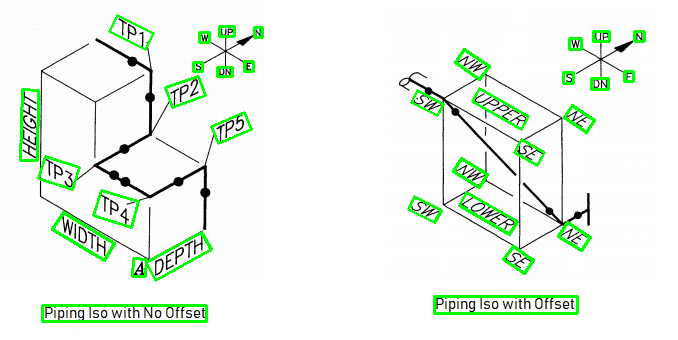

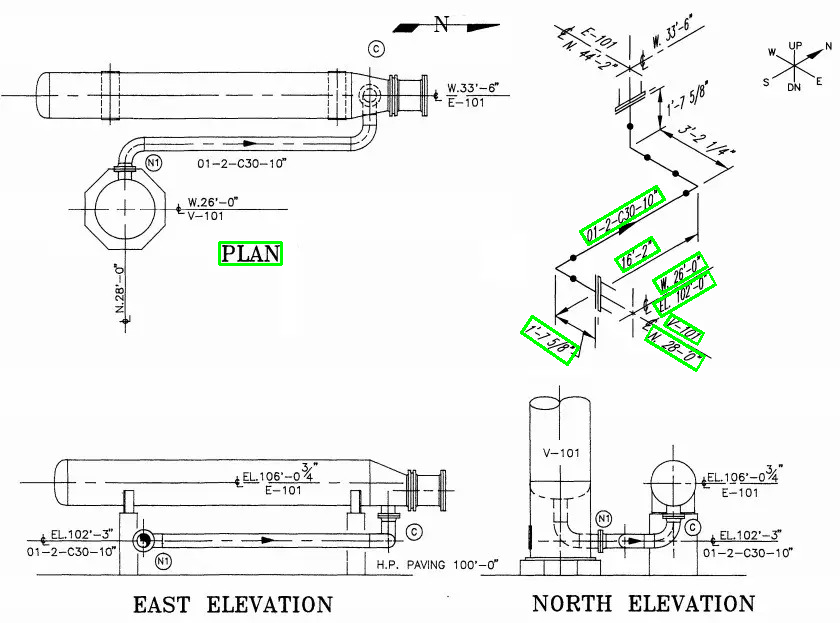

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import os # Ensure os module is imported for os.path.basename

for json in json_list:

  image_name = json['ocr']
  obboxes = json['bbox'] # list (x, y, width, height, rotation)
  transcription = json['transcription'] # list()

  # Correctly extract the filename and construct the image path
  image_filename = os.path.basename(image_name)
  image_path = os.path.join(IMAGES_PATH, image_filename)
  image = cv2.imread(image_path)

  # Check if the image was loaded successfully
  if image is None:
    print(f"Warning: Could not load image from {image_path}. Skipping.")
    continue # Skip to the next item in json_list

  for item in obboxes:
    obb = xywhrot_xyxyxyxy(item)
    cv2.polylines(image, [obb], True, (0, 255, 0), 2)


  cv2_imshow(image)
  # break